In [90]:
!pip install biopython -q
!apt-get install mafft -y -qq

In [91]:
from Bio import Entrez, SeqIO, AlignIO, Phylo
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
Entrez.email = "ashfamaf21@gmail.com"

In [93]:
species_list = [
    "Homo sapiens",
    "Pan troglodytes",
    "Mus musculus",
    "Rattus norvegicus",
    "Bos taurus",
    "Danio rerio"
]

In [94]:
records = []

for species in species_list:

    search = Entrez.esearch(
        db="protein",
        term=f'EGFR[Gene Name] AND "{species}"[Organism]',
        retmax=1
    )

    result = Entrez.read(search)

    if len(result["IdList"]) > 0:

        protein_id = result["IdList"][0]

        fetch = Entrez.efetch(
            db="protein",
            id=protein_id,
            rettype="fasta",
            retmode="text"
        )

        record = SeqIO.read(fetch, "fasta")

        record.id = species.replace(" ", "_")
        record.description = ""

        records.append(record)

        print(species, len(record.seq))

    else:
        print("No sequence found for", species)

Homo sapiens 1210
Pan troglodytes 1157
Mus musculus 1210
Rattus norvegicus 1195
Bos taurus 1208
Danio rerio 1191


In [95]:
SeqIO.write(
    records,
    "egfr_sequences.fasta",
    "fasta"
)

print("Sequences saved")

Sequences saved


In [96]:
!mafft --auto egfr_sequences.fasta > egfr_aligned.fasta

outputhat23=16
treein = 0
compacttree = 0
stacksize: 8192 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.505
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 6
done.

Progressive alignment ... 
STEP     5 /5 
done.
tbfast (aa) Version 7.505
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

    0 / 6
Segment   1/  1    1-1230
STEP 003-002-0  identical.   
Converged.

done
dvtditr (aa) Version 7.505
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 L-INS-i (Probably most accurate, very slow)
 Iterat

In [97]:
alignment = AlignIO.read(
    "egfr_aligned.fasta",
    "fasta"
)

print("Number of sequences:", len(alignment))
print("Alignment length:", alignment.get_alignment_length())

Number of sequences: 6
Alignment length: 1229


In [98]:
def identity(seq1, seq2):

    same = 0
    total = 0

    for a, b in zip(seq1, seq2):

        if a != "-" and b != "-":
            total += 1

            if a == b:
                same += 1

    return (same / total) * 100

In [99]:
names = [record.id for record in alignment]

matrix = []

for rec1 in alignment:

    row = []

    for rec2 in alignment:

        value = identity(
            str(rec1.seq),
            str(rec2.seq)
        )

        row.append(round(value, 2))

    matrix.append(row)

In [100]:
identity_df = pd.DataFrame(
    matrix,
    index=names,
    columns=names
)

identity_df

,Homo_sapiens,Pan_troglodytes,Mus_musculus,Rattus_norvegicus,Bos_taurus,Danio_rerio
Homo_sapiens,100.00,99.65,90.65,91.05,87.83,64.62
Pan_troglodytes,99.65,100.00,91.00,91.33,88.14,65.12
Mus_musculus,90.65,91.00,100.00,96.32,86.42,64.19
Rattus_norvegicus,91.05,91.33,96.32,100.00,87.20,64.71
Bos_taurus,87.83,88.14,86.42,87.20,100.00,64.93
Danio_rerio,64.62,65.12,64.19,64.71,64.93,100.00


In [101]:
identity_df.to_csv(
    "egfr_identity_matrix.csv"
)

In [102]:
conserved = []

for i in range(
    alignment.get_alignment_length()
):

    column = alignment[:, i]

    residues = [
        x for x in column
        if x != "-"
    ]

    if len(set(residues)) == 1:
        conserved.append(i + 1)

In [103]:
print(
    "Number of fully conserved positions:",
    len(conserved)
)

print(
    "First 20 conserved positions:",
    conserved[:20]
)

Number of fully conserved positions: 756
First 20 conserved positions: [1, 3, 13, 15, 25, 28, 29, 30, 31, 32, 33, 34, 37, 39, 40, 42, 43, 44, 46, 47]


In [104]:
percentage = (
    len(conserved)
    / alignment.get_alignment_length()
) * 100

print(
    "Fully conserved positions:",
    round(percentage, 2),
    "%"
)

Fully conserved positions: 61.51 %


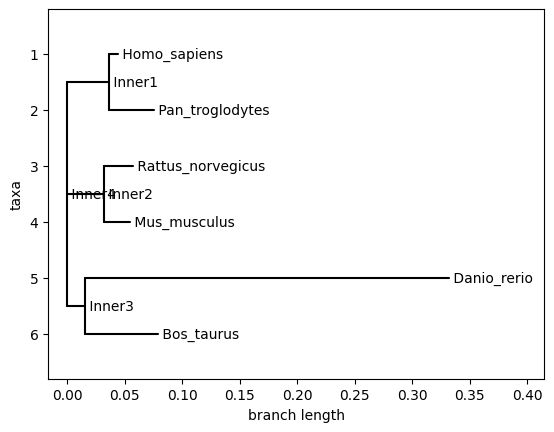

In [105]:
from Bio.Phylo.TreeConstruction import (
    DistanceCalculator,
    DistanceTreeConstructor
)

calculator = DistanceCalculator("identity")

distance_matrix = calculator.get_distance(
    alignment
)

constructor = DistanceTreeConstructor()

tree = constructor.nj(
    distance_matrix
)

Phylo.draw(tree)

In [106]:
human_seq = None

for record in alignment:
    if record.id == "Homo_sapiens":
        human_seq = str(record.seq)
        break

In [107]:
feature_rows = []

hydrophobic = set("AILMFWVY")

for record in alignment:

    seq = str(record.seq)

    ungapped_seq = seq.replace("-", "")

    seq_length = len(ungapped_seq)

    gap_count = seq.count("-")

    identity_to_human = identity(
        human_seq,
        seq
    )

    hydrophobic_count = sum(
        aa in hydrophobic
        for aa in ungapped_seq
    )

    hydrophobic_percent = (
        hydrophobic_count / seq_length
    ) * 100

    feature_rows.append({
        "Species": record.id,
        "Length": seq_length,
        "Identity_to_Human": identity_to_human,
        "Gap_Count": gap_count,
        "Hydrophobic_Percent": hydrophobic_percent
    })

In [108]:
feature_df = pd.DataFrame(feature_rows)

feature_df

,Species,Length,Identity_to_Human,Gap_Count,Hydrophobic_Percent
0,Homo_sapiens,1210,100.000000,19,35.702479
1,Pan_troglodytes,1157,99.654278,72,35.350043
2,Mus_musculus,1210,90.645695,19,36.115702
3,Rattus_norvegicus,1195,91.046025,34,36.234310
4,Bos_taurus,1208,87.831126,21,36.258278
5,Danio_rerio,1191,64.620631,38,35.516373


In [109]:
ml_features = feature_df[
    [
        "Length",
        "Identity_to_Human",
        "Gap_Count",
        "Hydrophobic_Percent"
    ]
]

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    ml_features
)

In [111]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    scaled_features
)

In [112]:
feature_df["PC1"] = pca_result[:, 0]
feature_df["PC2"] = pca_result[:, 1]

feature_df

,Species,Length,Identity_to_Human,Gap_Count,Hydrophobic_Percent,PC1,PC2
0,Homo_sapiens,1210,100.000000,19,35.702479,0.682821,0.734632
1,Pan_troglodytes,1157,99.654278,72,35.350043,-3.265790,0.779820
2,Mus_musculus,1210,90.645695,19,36.115702,1.321216,0.210100
3,Rattus_norvegicus,1195,91.046025,34,36.234310,0.517292,0.394541
4,Bos_taurus,1208,87.831126,21,36.258278,1.409854,0.073918
5,Danio_rerio,1191,64.620631,38,35.516373,-0.665392,-2.193012


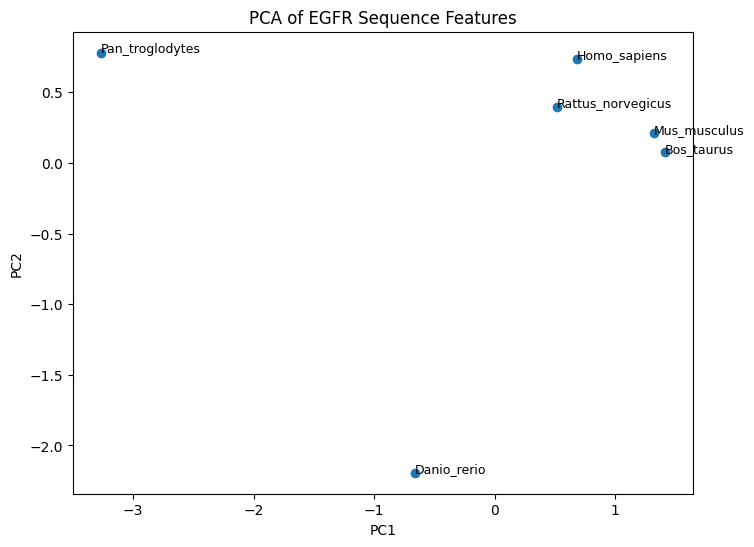

In [113]:
plt.figure(figsize=(8, 6))

plt.scatter(
    feature_df["PC1"],
    feature_df["PC2"]
)

for i, species in enumerate(feature_df["Species"]):

    plt.text(
        feature_df.loc[i, "PC1"],
        feature_df.loc[i, "PC2"],
        species,
        fontsize=9
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "PCA of EGFR Sequence Features"
)

plt.show()

In [114]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

feature_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

feature_df

,Species,Length,Identity_to_Human,Gap_Count,Hydrophobic_Percent,PC1,PC2,Cluster
0,Homo_sapiens,1210,100.000000,19,35.702479,0.682821,0.734632,0
1,Pan_troglodytes,1157,99.654278,72,35.350043,-3.265790,0.779820,1
2,Mus_musculus,1210,90.645695,19,36.115702,1.321216,0.210100,0
3,Rattus_norvegicus,1195,91.046025,34,36.234310,0.517292,0.394541,0
4,Bos_taurus,1208,87.831126,21,36.258278,1.409854,0.073918,0
5,Danio_rerio,1191,64.620631,38,35.516373,-0.665392,-2.193012,0


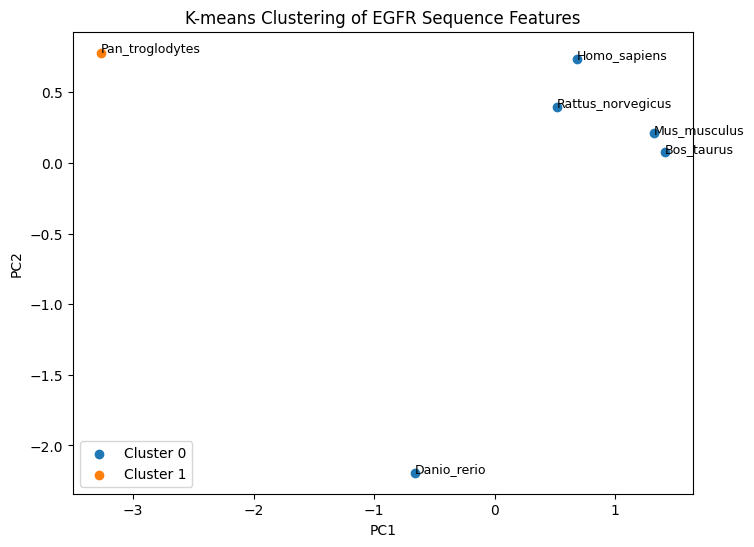

In [115]:
plt.figure(figsize=(8, 6))

for cluster in sorted(
    feature_df["Cluster"].unique()
):

    subset = feature_df[
        feature_df["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}"
    )

for i, species in enumerate(feature_df["Species"]):

    plt.text(
        feature_df.loc[i, "PC1"],
        feature_df.loc[i, "PC2"],
        species,
        fontsize=9
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "K-means Clustering of EGFR Sequence Features"
)

plt.legend()

plt.show()

In [116]:
# Save phylogenetic tree
Phylo.write(
    tree,
    "egfr_tree.nwk",
    "newick"
)

1

In [117]:
feature_df.to_csv(
    "egfr_sequence_ml_features.csv",
    index=False
)

print("ML feature results saved")

ML feature results saved


In [118]:
from google.colab import files

files.download("egfr_sequences.fasta")
# Save phylogenetic tree
Phylo.write(
    tree,
    "egfr_tree.nwk",
    "newick"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1

In [119]:
files.download("egfr_sequences.fasta")
files.download("egfr_tree.nwk")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Simple Machine Learning Extension

To complement the sequence and phylogenetic analysis, several numerical features were extracted from each aligned EGFR protein sequence, including protein length, identity to human EGFR, gap count and hydrophobic amino-acid percentage.

The features were standardized and analysed using Principal Component Analysis (PCA) for dimensionality reduction. K-means clustering was then applied to group species according to overall sequence characteristics.

The resulting clusters were compared qualitatively with the phylogenetic relationships obtained from the sequence alignment.